<a href="https://colab.research.google.com/github/nastya-kolle/mathematical-computational-modeling/blob/main/MCM_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №5. Модель «лекарство против раковых клеток»

**Задача.** Промоделировать систему «лекарство против раковых клеток» —
взаимное подавление двух величин, описываемое линейной системой ОДУ:

`A' = -β*B`, `B' = -α*A` (упрощённая модель, точное решение через `cosh`/`sinh`);

обобщённая модель с постоянным введением препарата и естественным ростом клеток:
`A' = -a*A - β*B + d`, `B' = e*B - α*A`.

Нужно получить аналитическое решение упрощённой модели, численно решить обобщённую
модель (с событием остановки, когда число раковых клеток `B(t)` обращается в ноль) и
определить момент "победы" препарата.


In [ ]:
import pandas
import numpy as np
import scipy
import sympy
import math
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [ ]:
alpha = 5.0 # скорость уничтожения раковых клеток одной единицей препарата
beta = 0.12  # скорость нейтрализации препарата одной единицей раковых клеток
A_0 = 100.0 # начальное количество препарата
B_0 = 500.0 # начальное количество раковых клеток
t_max = 5.0  # максимальное время моделирования
t_span = np.linspace(0, t_max, 1000)

In [ ]:
def exact_solution(t, A_0, B_0, alpha, beta):
  k = math.sqrt(alpha * beta)
  sqrt_alpha_beta = math.sqrt(alpha / beta)
  sqrt_beta_alpha = math.sqrt(beta / alpha)
  A = A_0 * np.cosh(k * t) - sqrt_beta_alpha * B_0 * np.sinh(k * t)
  B = B_0 * np.cosh(k * t) - sqrt_alpha_beta * A_0 * np.sinh(k * t)
  return A, B

# Находим время победы (когда B(t) = 0)
t_star = fsolve(lambda t: exact_solution(t, A_0, B_0, alpha, beta)[1], 1.0)[0]
print(f"Время уничтожения раковых клеток: t* = {t_star:.4f}")

# Создаём временную сетку ТОЛЬКО до момента победы
t_span = np.linspace(0, t_star, 1000)

# Вычисляем точное решение
A_exact, B_exact = exact_solution(t_span, A_0, B_0, alpha, beta)

# Квадратичный закон Ланчестера
C = alpha * A_0**2 - beta * B_0**2
print(f"\nКвадратичный закон: C = {C:.2f}")
if C > 0:
    print("ПРЕПАРАТ ПОБЕЖДАЕТ")
elif C < 0:
    print("РАК ПОБЕЖДАЕТ")
else:
    print("НИЧЬЯ")

print(f"Параметры: α = {alpha}, β = {beta}")
print(f"Начальные условия: A(0) = {A_0}, B(0) = {B_0}")
print(f"Константа квадратичного закона: C = {C:.2f}")
print(f"Результат: {'ПРЕПАРАТ ПОБЕЖДАЕТ' if C > 0 else 'РАК ПОБЕЖДАЕТ' if C < 0 else 'НИЧЬЯ'}")

Время уничтожения раковых клеток: t* = 1.3319

Квадратичный закон: C = 20000.00
ПРЕПАРАТ ПОБЕЖДАЕТ
Параметры: α = 5.0, β = 0.12
Начальные условия: A(0) = 100.0, B(0) = 500.0
Константа квадратичного закона: C = 20000.00
Результат: ПРЕПАРАТ ПОБЕЖДАЕТ


In [ ]:
# Дополнительные коэффициенты для обобщённой модели
a = 0.05 # естественный распад препарата
d = 10.0 # постоянное введение препарата
e = -0.02  # естественный рост раковых клеток (отрицательный = рост)

In [ ]:
def generalized_model(t, y, alpha, beta, a, d, e):
  A, B = y
  dA_dt = -a * A - beta * B + d
  dB_dt = e * B - alpha * A
  return [dA_dt, dB_dt]

def event_stop(t, y, alpha, beta, a, d, e):
    return y[1]  # B(t)
event_stop.terminal = True
event_stop.direction = -1
# Решаем численно
solution = solve_ivp(generalized_model, [0, t_max], [A_0, B_0], args= (alpha, beta, a, d, e), t_eval=t_span, method='RK45', rtol=1e-8, atol=1e-10, events=event_stop, dense_output=True)

t_num = solution.t
A_num = solution.y[0]
B_num = solution.y[1]
t_star_num = t_num[-1]

print(f"Дополнительные параметры: a = {a}, d = {d}, e = {e}")
print(f"A({t_max}) = {A_num[-1]:.2f}")
print(f"B({t_max}) = {B_num[-1]:.2f}")

Дополнительные параметры: a = 0.05, d = 10.0, e = -0.02
A(5.0) = 72.56
B(5.0) = 0.41


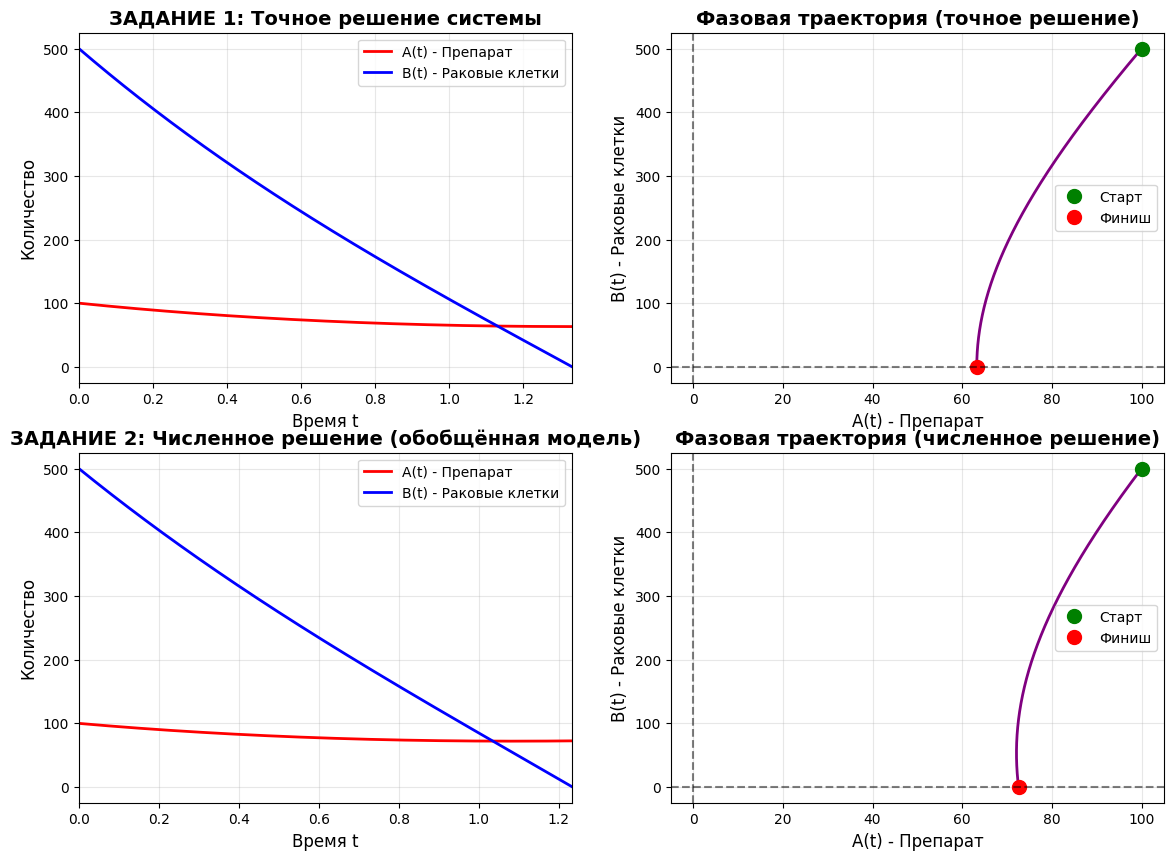

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 1: Точное решение - динамика A(t) и B(t)
axes[0, 0].plot(t_span, A_exact, "-r", linewidth= 2, label="A(t) - Препарат")
axes[0, 0].plot(t_span, B_exact, "-b", linewidth= 2, label="B(t) - Раковые клетки")
axes[0, 0].set_xlabel("Время t", fontsize=12)
axes[0, 0].set_ylabel("Количество", fontsize=12)
axes[0, 0].set_title("ЗАДАНИЕ 1: Точное решение системы", fontsize= 14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xlim([0, t_star])

# График 2: Точное решение - фазовая траектория
axes[0, 1].plot( A_exact, B_exact, "purple", linewidth= 2)
axes[0, 1].plot(A_exact[0], B_exact[0], "go", markersize=10, label="Старт")
axes[0, 1].plot(A_exact[-1], B_exact[-1], "ro", markersize=10, label="Финиш")
axes[0, 1].axhline(y=0, color='k', linestyle='--', alpha=0.5)
axes[0, 1].axvline(x=0, color='k', linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel("A(t) - Препарат", fontsize=12)
axes[0, 1].set_ylabel("B(t) - Раковые клетки", fontsize=12)
axes[0, 1].set_title("Фазовая траектория (точное решение)", fontsize= 14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# График 3: Численное решение - динамика A(t) и B(t)
axes[1, 0].plot(solution.t, A_num, "-r", linewidth= 2, label="A(t) - Препарат")
axes[1, 0].plot(solution.t, B_num, "-b", linewidth= 2, label="B(t) - Раковые клетки")
axes[1, 0].set_xlabel("Время t", fontsize=12)
axes[1, 0].set_ylabel("Количество", fontsize=12)
axes[1, 0].set_title("ЗАДАНИЕ 2: Численное решение (обобщённая модель)", fontsize= 14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xlim([0, t_star_num])

# График 4: Численное решение - фазовая траектория
axes[1, 1].plot( A_num, B_num, "purple", linewidth= 2)
axes[1, 1].plot(A_num[0], B_num[0], "go", markersize=10, label="Старт")
axes[1, 1].plot(A_num[-1], B_num[-1], "ro", markersize=10, label="Финиш")
axes[1, 1].axhline(y=0, color='k', linestyle='--', alpha=0.5)
axes[1, 1].axvline(x=0, color='k', linestyle='--', alpha=0.5)
axes[1, 1].set_xlabel("A(t) - Препарат", fontsize=12)
axes[1, 1].set_ylabel("B(t) - Раковые клетки", fontsize=12)
axes[1, 1].set_title("Фазовая траектория (численное решение)", fontsize= 14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)